# Setup
- Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"
- Install TerraTorch
    - You will have to restart the session after installing terratorch (it kinda looks like an error)

In [1]:
!pip install terratorch==1.1.1
!pip install gdown tensorboard zarr earthaccess folium

In [25]:
from datetime import datetime, timedelta
import gdown
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from rasterio.plot import show
import numpy as np
import earthaccess

from shapely import wkt
from shapely.geometry import polygon

import folium
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin

from torchgeo.datasets import RasterDataset, stack_samples, unbind_samples, utils
from torchgeo.samplers import RandomGeoSampler
from torch.utils.data import DataLoader
import logging

import terratorch
logging.getLogger().setLevel(logging.WARNING)

# Download the HWDS dataset

In [26]:
hwds_google_drive_id = '1TC7JsbrSGTpS0CEvEbGp9TqtxDjAdLBG'
drive_url = f'https://drive.google.com/uc?id={hwds_google_drive_id}'
filename = '25_hwds_shapefile'

if not Path(f'{filename}.zip').exists():
  gdown.download(drive_url)
  !unzip 25_hwds_shapefile.zip

shp_path = Path(filename) / 'hls_hwds_polygons.shp'

# Load the data using geopandas

In [27]:
gdf = gpd.read_file(shp_path)

2019-05-17


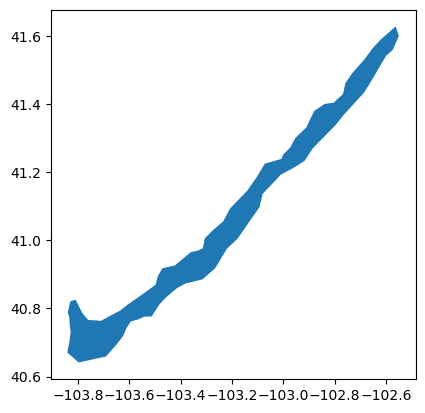

In [28]:
swath_id = '97'
swath_gdf = gdf[gdf['swathID'] == swath_id]
swath = swath_gdf.iloc[0]

best_post_date = datetime(year=2019, month=5, day=24) # Update this for different swaths

swath_gdf.plot()
print(swath['swathDate'])

# Find hls data based on polygon

In [29]:
earthaccess.login()

In [30]:
geometry = polygon.orient(swath.geometry, sign=1.0)

results = earthaccess.search_data(
    short_name='HLSS30',
    polygon=list(geometry.exterior.coords),
    temporal=(best_post_date, best_post_date + timedelta(days=1))
)

In [31]:
geotiff_list = results

def plot_geotiff_extents(results_list, selected_gdf):
    all_lats, all_lons = [], []
    
    m = folium.Map(tiles="CartoDB positron")

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    color_index = 0

    for metadata in results_list:
        points = metadata['umm']['SpatialExtent']['HorizontalSpatialDomain']['Geometry']['GPolygons'][0]['Boundary']['Points']
        
        footprint_coords = []
        for point in points:
            lat = point['Latitude']
            lon = point['Longitude']
            footprint_coords.append((lat, lon))
            all_lats.append(lat)
            all_lons.append(lon)
        
        tile_name = metadata['umm']['GranuleUR']
        try:
            if 'Data' in metadata and metadata['Data']:
                 url_parts = metadata['Data'][0].split('/')
                 tile_name = url_parts[-2].split('.')[2]
        except:
             pass

        current_color = colors[color_index % len(colors)]
        color_index += 1

        folium.Polygon(
            locations=footprint_coords,
            tooltip=f"Extent: {tile_name}",
            color=current_color,
            weight=3,
            fill=True,
            fill_color=current_color,
            fill_opacity=0.3
        ).add_to(m)
        
    folium.GeoJson(
        selected_gdf.to_json(),
        style_function=lambda x: {
            'fillColor': '#8c564b', 
            'color': '#8c564b',
            'weight': 4,
            'fillOpacity': 0.5
        },
        tooltip=folium.features.GeoJsonTooltip(fields=['swathID', 'swathDate'], aliases=['ID:', 'Date:'], localize=True)
    ).add_to(m)
    
    if all_lats and all_lons:
        min_lat = min(all_lats)
        max_lat = max(all_lats)
        min_lon = min(all_lons)
        max_lon = max(all_lons)
        
        map_bounds = [[min_lat, min_lon], [max_lat, max_lon]]
        m.fit_bounds(map_bounds)

    folium.LayerControl().add_to(m)
    
    return m


In [32]:
final_map = plot_geotiff_extents(results, swath_gdf)
final_map

In [33]:
data_path = Path.cwd() / 'data'
hls_path = data_path / 'HLS'
label_path = data_path / 'LABEL'

for data_path in (hls_path, label_path):
    data_path.mkdir(parents=True, exist_ok=True) 

In [34]:
files = earthaccess.download(
    results,
    local_path=hls_path  # Specify where to save files
)

QUEUEING TASKS | :   0%|          | 0/126 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/126 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/126 [00:00<?, ?it/s]

## Turn label geometry into raster

In [35]:
utm_crs = gdf.estimate_utm_crs()
gdf_crs = gdf.to_crs(utm_crs)

swath_crs_gdf = gdf_crs[gdf_crs['swathID'] == swath_id]

In [36]:
def rasterize_swath(selected_swath_gdf):
    pixel_size_meters = 10
    padding_meters = 1000

    selected = selected_swath_gdf.iloc[0]
    geom = selected.geometry
    minx, miny, maxx, maxy = geom.bounds
    minx -= padding_meters
    miny -= padding_meters
    maxx += padding_meters
    maxy += padding_meters

    width = int(np.ceil((maxx - minx) / pixel_size_meters))
    height = int(np.ceil((maxy - miny) / pixel_size_meters))

    transform = from_origin(minx, maxy, pixel_size_meters, pixel_size_meters)

    rasterized = rasterize(
        [(geom, 1)],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype='uint8'
    )

    out_path = label_path / f'swathID_{swath_id}.tif'

    with rasterio.open(
        out_path, 'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype='uint8',
        crs=selected_swath_gdf.crs,
        transform=transform
    ) as dst:
        dst.write(rasterized, 1)
        dst.update_tags(polygon_id=str(swath_id))
    
    return out_path

label_raster = rasterize_swath(swath_crs_gdf)

## Visualize Label Raster

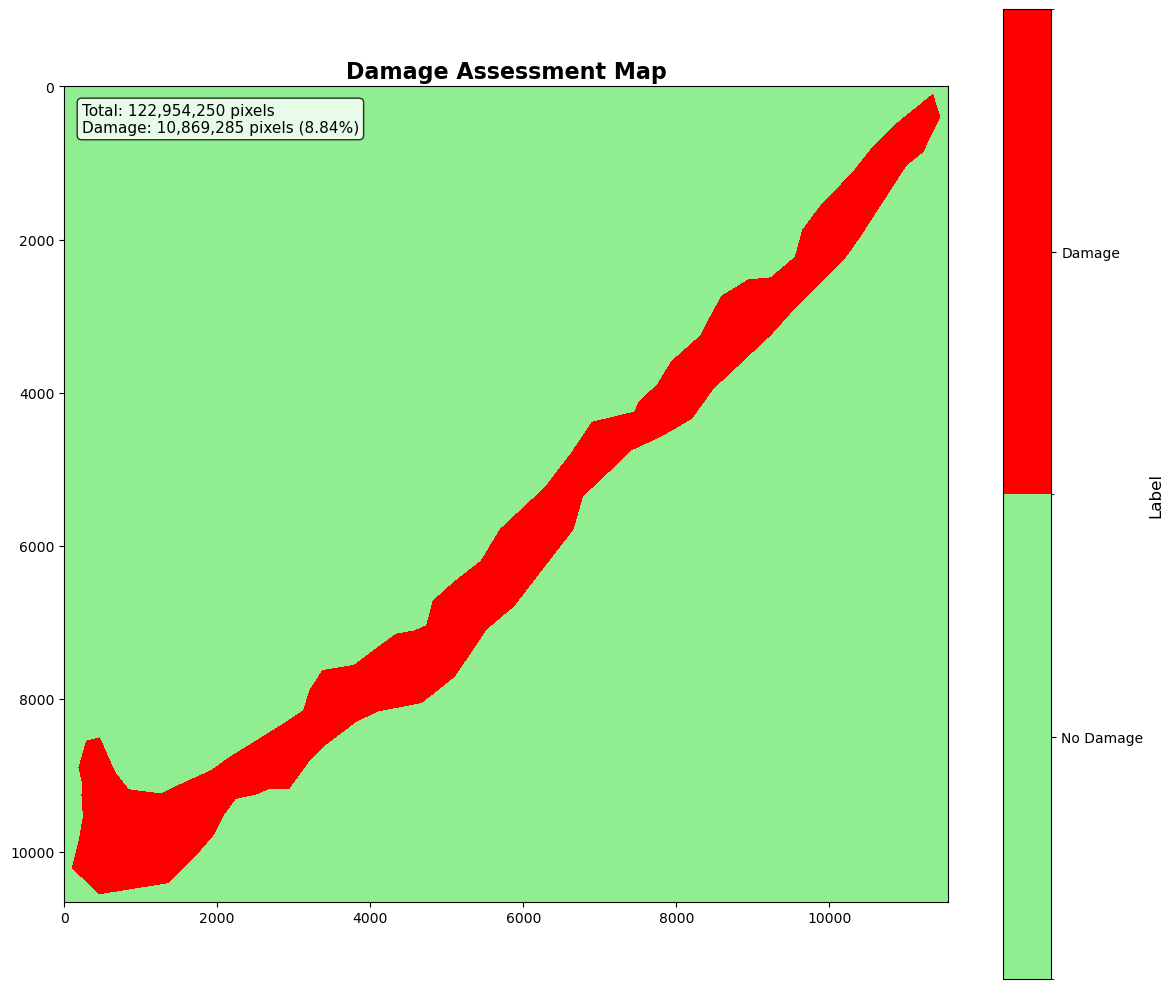

In [37]:
with rasterio.open(label_raster) as src:
    data = src.read(1)
    
    colors = ['lightgreen', 'red']  # 0=no damage, 1=damage
    cmap = mcolors.ListedColormap(colors)
    bounds = [-0.5, 0.5, 1.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(data, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title('Damage Assessment Map', fontsize=16, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.set_label('Label', fontsize=12)
    cbar.ax.set_yticklabels(['No Damage', 'Damage'])
    
    total_pixels = data.size
    damage_pixels = np.sum(data == 1)
    damage_pct = (damage_pixels / total_pixels) * 100
    
    textstr = f'Total: {total_pixels:,} pixels\nDamage: {damage_pixels:,} pixels ({damage_pct:.2f}%)'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()

## Setup DataModule 

In [38]:
class HLSDataset(RasterDataset):
    """
    HLS dataset using TorchGeo's RasterDataset base class.
    
    Example file name:
        HLS.S30.T13TFF.2019144T173909.v2.0.B08.tif

    Bands:
        B01 ->  COASTAL
        B02 ->  BLUE
        B03 ->  GREEN
        B04 ->  RED
        B05 ->  REDEDGE1
        B06 ->  REDEDGE2
        B07 ->  REDEDGE3
        B08 ->  NIR
        B8A ->  NIR08
        B09 ->  NIR09
        B11 ->  SWIR16
        B12 ->  SWIR22
    """
    
    filename_glob = "HLS.*.tif"
    filename_regex = r"^HLS\.(?P<sensor>[SL])30\.(?P<tile>T\w+)\.(?P<date>\d+T\d+)\.v\d+\.\d+\.(?P<band>B\w+|SZA|SAA|VZA|VAA)\.tif$"
    date_format = '%Y%d%mT%H%M%S'
    
    separate_files = True
    is_image = True
    
    all_bands = ("B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B10", "B11", "B12", "Fmask")
    rgb_bands = ('B04', 'B03', 'B02')

class LabelDataset(RasterDataset):
    filename_glob = "swathID_*.tif"
    is_image = False

In [39]:
import torch
from torch.utils.data import DataLoader
from lightning import LightningDataModule
from torchgeo.datasets import RasterDataset
from torchgeo.datasets.utils import stack_samples
from torchgeo.samplers import RandomGeoSampler

def terramind_collate(batch):
    stacked = stack_samples(batch)
    return {
        'image': {
            'S2L2A': stacked['image']
        },
        'mask': stacked['mask']
    }


class HLSDataModule(LightningDataModule):  
    def __init__(
        self,
        hls_path: str,
        label_path: str,
        batch_size: int = 8,
        patch_size: int = 224,
        train_length: int = 10000,
        val_length: int = 2000,
        num_workers: int = 4,
    ):
        super().__init__()
        self.hls_path = hls_path
        self.label_path = label_path
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.train_length = train_length
        self.val_length = val_length
        self.num_workers = num_workers
        
    def setup(self, stage=None):
        hls_dataset = HLSDataset(
            paths=self.hls_path,
            bands=('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 
                   'B07', 'B08', 'B8A', 'B09', 'B11', 'B12')
        )
        
        label_dataset = LabelDataset(paths=self.label_path)
        
        self.dataset = label_dataset & hls_dataset
        
        # Create samplers
        self.train_sampler = RandomGeoSampler(
            self.dataset,
            size=self.patch_size,
            length=self.train_length
        )
        self.val_sampler = RandomGeoSampler(
            self.dataset,
            size=self.patch_size,
            length=self.val_length
        )
    
    def train_dataloader(self):
        return DataLoader(
            self.dataset,
            sampler=self.train_sampler,
            batch_size=self.batch_size,
            collate_fn=terramind_collate,
            num_workers=self.num_workers
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.dataset,
            sampler=self.val_sampler,
            batch_size=self.batch_size,
            collate_fn=terramind_collate,
            num_workers=self.num_workers
        )


In [40]:
datamodule = HLSDataModule(
    hls_path=hls_path,
    label_path=label_path,
    batch_size=8
)

datamodule.setup()

Converting HLSDataset CRS from EPSG:32613 to EPSG:32614
Converting HLSDataset res from (30.0, 30.0) to (10.0, 10.0)


In [41]:
# Test
for batch in datamodule.train_dataloader():
    print(batch['image']['S2L2A'].shape, batch['mask'].shape)
    break

torch.Size([8, 12, 224, 224]) torch.Size([8, 224, 224])


In [42]:
MODALITIES = ['S2L2A']

model = terratorch.tasks.SemanticSegmentationTask(
  model_factory='EncoderDecoderFactory',
  model_args={
      'backbone': 'terramind_v1_base',
      'backbone_pretrained': True,
      'backbone_modalities': MODALITIES,
      'necks': [
          {'name': 'SelectIndices', 'indices': [2, 5, 8, 11]},
          {'name': 'ReshapeTokensToImage', 'remove_cls_token': False},
          {'name': 'LearnedInterpolateToPyramidal'}
      ],
      'decoder': 'UNetDecoder',
      'decoder_channels': [512, 256, 128, 64],
      'head_dropout': 0.1,
      'num_classes': 2,
  },
  loss='dice',
  optimizer='AdamW',
  lr=1e-5,
  ignore_index=-1,
  freeze_backbone=True,
  freeze_decoder=False,
  plot_on_val=False,
  class_names=['no-damage', 'damage'],
)


In [43]:
import lightning.pytorch as pl
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import LearningRateMonitor

# TensorBoard logger
tb_logger = TensorBoardLogger(
  save_dir='output/terramind_base_hwds/',
  name='tensorboard_logs',
)

# Callbacks
checkpoint_callback = pl.callbacks.ModelCheckpoint(
  dirpath='output/terramind_base_hwds/checkpoints/',
  filename='best-epoch{epoch:02d}-mIoU{val/mIoU:.4f}',
  monitor='val/mIoU',
  mode='max',
  save_top_k=1,
  save_last=True,
  save_weights_only=False,
  auto_insert_metric_name=False,
)

lr_monitor = LearningRateMonitor(logging_interval='step')

trainer = pl.Trainer(
  accelerator='auto',
  strategy='auto',
  num_nodes=1,
  logger=tb_logger,
  max_epochs=10,
  log_every_n_steps=5,
  callbacks=[
      checkpoint_callback,
      lr_monitor,
      pl.callbacks.RichProgressBar()
  ],
  default_root_dir='output/terramind_base_hwds/',
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [44]:
%load_ext tensorboard
%tensorboard --logdir output

In [ ]:
trainer.fit(model, datamodule=datamodule)

Converting HLSDataset CRS from EPSG:32613 to EPSG:32614
Converting HLSDataset res from (30.0, 30.0) to (10.0, 10.0)


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  102 M │ train │
│ 1 │ criterion     │ DiceLoss         │      0 │ train │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │
└───┴───────────────┴──────────────────┴────────┴───────┘

Trainable params: 15.5 M                                                                                           
Non-trainable params: 87.3 M                                                                                       
Total params: 102 M                                                                                                
Total estimated model params size (MB): 411                                                                        
Modules in train mode: 288                                                                                         
Modules in eval mode: 0

Output()